In [14]:
!pip install -r ../requirements.txt


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


| 컬럼명 | 설명 |
| --- | --- |
| `hotel` | 호텔명 (`Resort Hotel` 혹은 `City Hotel`) |
| `is_canceled` | 호텔 예약이 취소되었는지(1) 혹은 취소되지 않았는지(0)를 나타내는 값 |
| `lead_time` | 호텔 예약 시점부터 고객의 호텔 도착 시점까지의 기간 (단위: 날짜) |
| `arrival_date_year` | 고객의 호텔 도착 연도 |
| `arrival_date_month` | 고객의 호텔 도착 월 |
| `arrival_date_week_number` | 고객의 호텔 도착 주 <br> 예: 2015년도 셋째 주에 도착 → `arrival_date_week_number = 3` |
| `arrival_date_day_of_month` | 고객의 호텔 도착 일 <br> 예: 3월 2일에 도착 → `arrival_date_day_of_month = 2` |
| `stays_in_weekend_nights` | 고객이 호텔에 숙박했거나 예약한 주말 밤 수(토요일~일요일) <br> 예: 평일 3일, 주말 2일 예약 → `stays_in_weekend_nights = 2` |
| `stays_in_week_nights` | 고객이 호텔에 숙박했거나 예약한 주중 밤 수(월요일~금요일) <br> 예: 평일 3일, 주말 2일 예약 → `stays_in_week_nights = 3` |
| `adults` | 예약된 어른의 수 |
| `children` | 예약된 어린이의 수 |
| `babies` | 예약된 아기의 수 |
| `meal` | 예약된 식사 유형 <br> - `Undefined/SC`: 식사가 포함되지 않은 옵션 <br> - `BB`: Bed & Breakfast 옵션 <br> - `HB`: Half Board (아침 식사 및 추가 식사 1회, 일반적으로 저녁 식사) 옵션 <br> - `FB`: Full Board (아침, 점심, 저녁) |
| `country` | 투숙객의 출신 국가. 카테고리는 ISO 3155-3:2013 형식으로 표시 |
| `market_segment` | 시장 세그먼트. `TA`는 Travel Agent, `TO`는 Tour Operators를 의미 |
| `distribution_channel` | 예약 유통 채널. `TA`는 Travel Agent, `TO`는 Tour Operators를 의미 |
| `is_repeated_guest` | 이전에 방문했던 손님인지(1) 아닌지(0)를 나타내는 값 |
| `previous_cancellations` | 현재 예약 이전에 고객이 취소한 이전 예약 수 |
| `previous_bookings_not_canceled` | 현재 예약 이전에 고객이 취소하지 않은 이전 예약 수 |
| `reserved_room_type` | 예약한 룸 타입 코드 |
| `assigned_room_type` | 실제 배정된 룸 타입 코드. 호텔 운영상의 이유(예: 초과 예약 등) 또는 고객 요청으로 인해 예약한 객실과 다른 객실 유형이 배정되는 경우가 존재 |
| `booking_changes` | 예약 시점부터 예약 취소 또는 체크인 시점까지 예약에 대한 변경/수정 횟수 |
| `agent` | 예약을 진행한 여행사의 ID |
| `company` | 예약을 하였거나 예약금을 지불할 책임이 있는 회사 또는 단체의 ID |
| `days_in_waiting_list` | 예약이 확정되기 전까지 해당 예약이 예약 대기자 명단에 있었던 일수 |
| `required_car_parking_spaces` | 고객이 요구하는 주차 공간 수 |
| `total_of_special_requests` | 고객의 특별 요청 건수 (예: 트윈 베드, 아기 침대, 고층, 특별한 뷰 등) |
| `reservation_status` | 예약의 마지막 상태 <br> - `Canceled`: 고객이 예약을 취소함 <br> - `Check-Out`: 고객이 체크인을 하고 체크아웃함 <br> - `No-Show`: 고객이 체크인을 하지 않았고 해당 이유를 알 수 없음 |
| `reservations_status_date` | 마지막 예약 상태(`reservation_status`)가 설정된 날짜 |

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df = pd.read_csv('../data/hotel_data_modified.csv')

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,reserved_room_type,assigned_room_type,booking_changes,agent,company,days_in_waiting_list,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,C,C,3,NaN,NaN,0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,C,C,4,NaN,NaN,0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,A,C,0,NaN,NaN,0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,A,A,0,304.0,NaN,0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,A,A,0,240.0,NaN,0,0,1,Check-Out,2015-07-03


In [17]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,8.000000,5.000000


In [18]:
# 값이 비어 있는 열이 company, agent -> company나 agent가 비어 있는 열은 개인 예약 고객
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 29 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

### 데이터 안에 NULL 처리
`country`,`agent`,`company`에 null 값이 존재함을 인지함.<br>
`country`는 고객이 정보 제공 미동의로 정의<br>
`agent`와 `company`는 정수 데이터이므로 비어 있는 곳은 일단 오류 방지를 위해 0으로 처리함.<br>
`reservation_status_date`는 datetime type으로 변환

In [19]:
clean_df = df.copy()
# country, agent, company에서 비어 있는 값 발견하여, country는 고객이 공개하기 싫어 조사 거부로 생각하
clean_df = clean_df.fillna(0)
clean_df.isna().sum()
clean_df['reservation_status_date'] = pd.to_datetime(clean_df['reservation_status_date'])
clean_df['market_segment'].value_counts()

market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64

### 호텔별 취소율 분석

1. 전체 취소 건수 중에 호텔 별로 얼마나 차지
확인 결과: City Hotel 74.9%, Resort Hotel 25.1%로 City Hotel이 앞도적으로 높은 것을 확인

2. 호텔별 전체 예약 건수 중 취소율이 몇 퍼센트인가
확인 결과: City Hotel canceled 41.7%, Resort Hotel 27.8%로 City Hotel이 예약건수 대비 취소율이 높은 것을 확인

전체 취소 건수가 높아, 단순히 City Hotel이 예약건수가 많아서 인지 확인하기 위해 호텔 별 예약 건수 중 취소율을 확인하였을 때도 City Hotel 취소율이 더 높은 것을 확인하여 City Hotel이 취소율이 높은 호텔이라는 것을 인지하였습니다. 다만, City Hotel의 예약건수가 Resort Hotel의 약 2배 정도를 가지고 있기 때문에 단정할 수 없다.

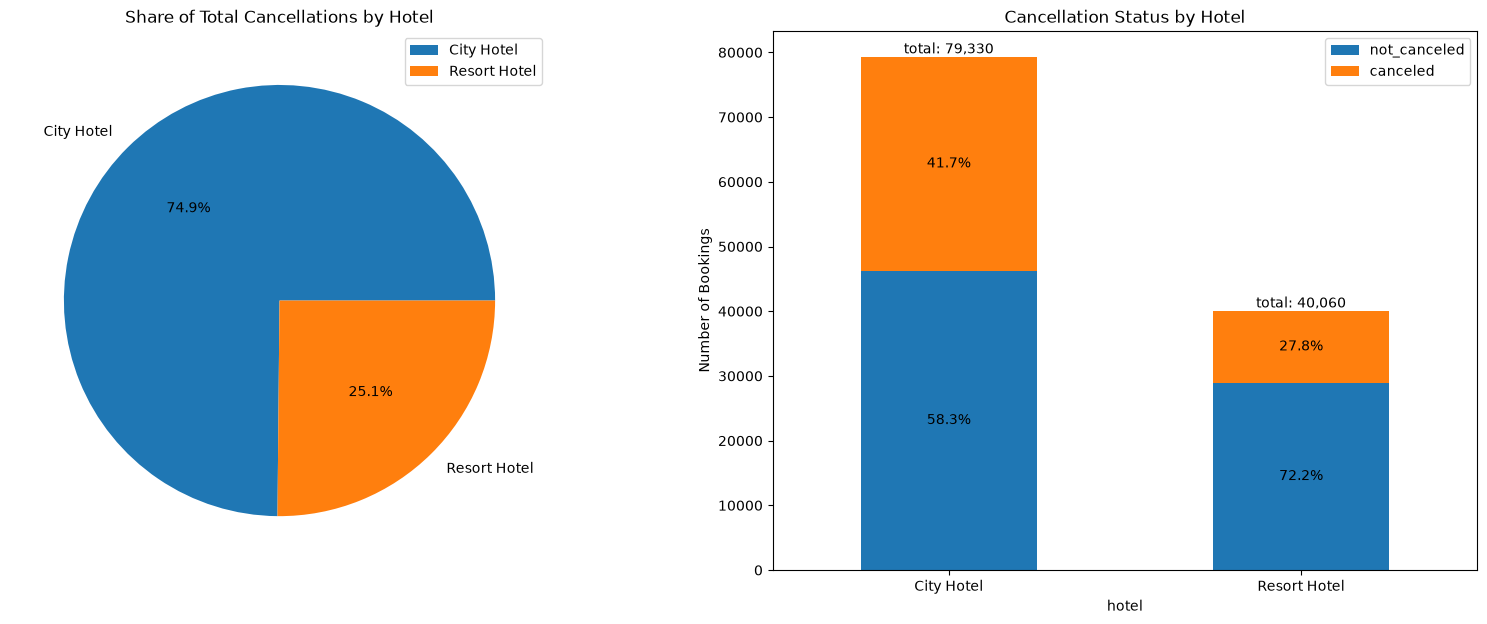

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

hotel_by_cancel_summary =(
    clean_df
        .groupby('hotel')['is_canceled']
        .agg(['count', 'sum'])
)
canceled = hotel_by_cancel_summary['sum']
total_booking =hotel_by_cancel_summary['count']
not_canceled = total_booking - canceled


hotel_by_is_cancel = pd.DataFrame(
    data={
            'not_canceled': not_canceled,
            'canceled': canceled
            },
    index=hotel_by_cancel_summary.index,
    columns=['not_canceled', 'canceled']
    )

hotel_by_is_cancel_per = pd.DataFrame(
    data={
            'not_canceled': not_canceled / total_booking,
            'canceled': canceled / total_booking
            
            },
    index=hotel_by_cancel_summary.index,
    columns=['not_canceled', 'canceled']
)


# hotel_by_cancel_summary['sum']
axes[0].pie(hotel_by_cancel_summary['sum'], labels=hotel_by_cancel_summary.index, autopct='%.1f%%')
axes[0].set_title('Share of Total Cancellations by Hotel')

ax_1 = hotel_by_is_cancel.plot(
    kind='bar',
    stacked=True,
    ax=axes[1]
)

axes[1].set_title('Cancellation Status by Hotel')
axes[1].tick_params(axis='x', labelrotation=0)
axes[1].set_ylabel('Number of Bookings')

for container, column_name in zip(
    ax_1.containers, 
    hotel_by_is_cancel_per
):
    
    # ax_1.bar_label(container)
    labels = [
        f'{value:.1%}'
        for value in hotel_by_is_cancel_per[column_name]
    ]
    # print(labels)

    ax_1.bar_label(
        container,
        labels=labels,
        label_type='center'
    )

for i, total in enumerate(total_booking):
    ax_1.text(
        i,
        total,
        f'total: {total:,}',
        ha='center',
        va='bottom'
    )

axes[0].legend()
axes[1].legend()
plt.show()


### 고객 예약 유형 별 취소
`market_segment`에 따른 취소 건수를 확인하였을 때 Online TA가 20,739건으로 1등, Groups가 12,097건으로 2등이다.<br>
따라서, 이 데이터로는 Online TA가 접근이 쉬운만큼 취소율이 높다.<br>
Other는 100건의 이하의 예약건들로 `Complementary`, `Aviation`, `Undefined`이다.

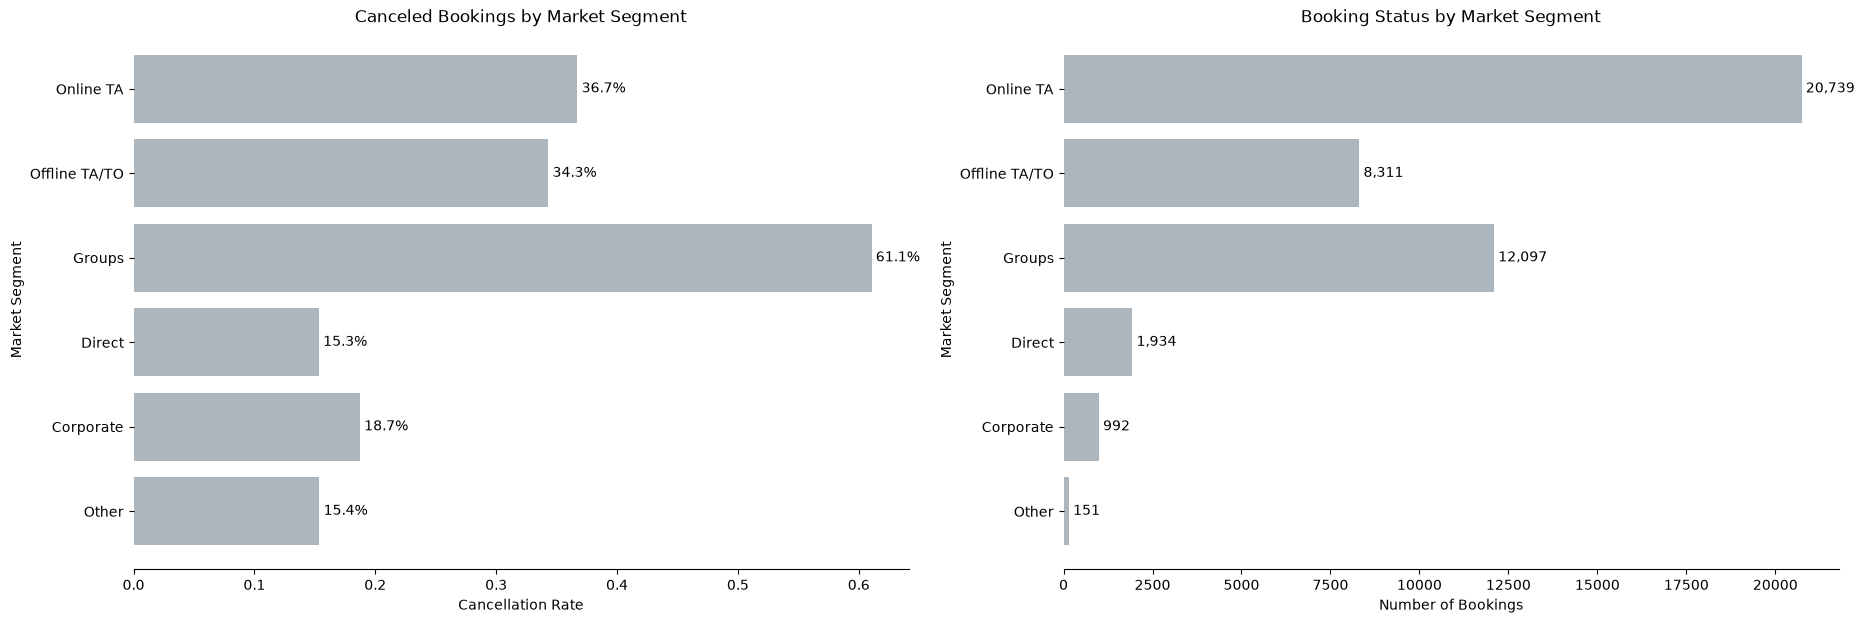

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(22,7))


market_segment_by_canceled_summary = (
    clean_df
        .groupby('market_segment')['is_canceled']
        .agg(['count', 'sum'])
        # .sort_values('sum')
)

smaller_mask = market_segment_by_canceled_summary['count'] <= 1000

market_segment_by_canceled_summary['canceled_rate'] = market_segment_by_canceled_summary['sum'] / market_segment_by_canceled_summary['count']
market_segment_by_canceled_summary['not_canceled_rate'] = 1 - market_segment_by_canceled_summary['canceled_rate']

main_summary = market_segment_by_canceled_summary.loc[~smaller_mask]
other_summary = market_segment_by_canceled_summary.loc[smaller_mask]

other_cancel_rate = (
    other_summary['sum'].sum()
    /
    other_summary['count'].sum()
)

other_not_cancel_rate = 1 - other_cancel_rate


# main_summary
all_canceled_graph = pd.concat(
    [
        pd.Series({'Other': other_summary['sum'].sum()}),
        main_summary['sum'],
    ]
)

all_not_canceled_graph = pd.concat(
    [
        pd.Series({'Other': (other_summary['count'] - other_summary['sum']).sum()}),
        (main_summary['count'] - main_summary['sum']),
    ]
)


canceled_graph_df = pd.concat(
    [
        pd.Series({'Other': other_cancel_rate}),
        main_summary['canceled_rate'],
    ]
)

order = canceled_graph_df.index

all_canceled_graph = all_canceled_graph.loc[order]
all_not_canceled_graph = all_not_canceled_graph.loc[order]

bars_1 = axes[0].barh(canceled_graph_df.index, canceled_graph_df.values, color="#adb5bd")

# axes.yaxesis_inverted(True)
bars_2 = axes[1].barh(all_canceled_graph.index, all_canceled_graph.values, color="#adb5bd")

axes[0].bar_label(bars_1, fmt='{:,.1%}', padding=3)

axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].spines['left'].set_visible(False)

axes[0].set_xlabel('Cancellation Rate')
axes[0].set_ylabel('Market Segment')
axes[0].set_title('Canceled Bookings by Market Segment')

axes[1].bar_label(bars_2, fmt='{:,.0f}', padding=3)

axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['left'].set_visible(False)
# axes[0].spines['bottom'].set_visible(False)

axes[1].set_xlabel('Number of Bookings')
axes[1].set_ylabel('Market Segment')
axes[1].set_title('Booking Status by Market Segment')


plt.show()

### 고객들의 예약 시기 흐름
고객들이 호텔 도착 0-100일 사이에 가장 예약을 많이 함을 확인하였다.

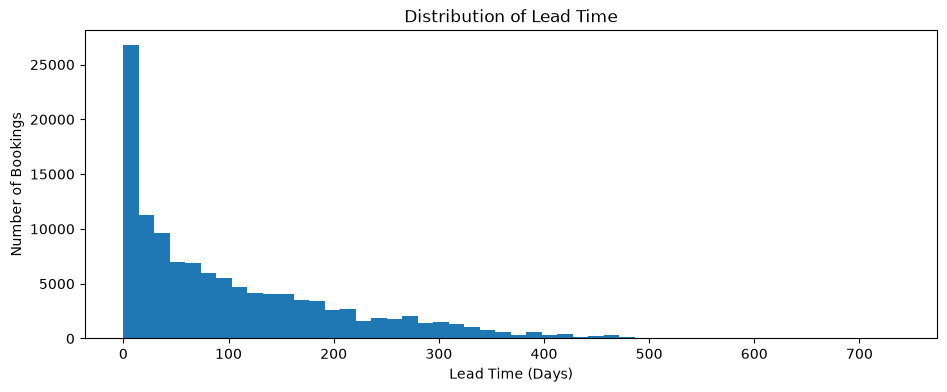

In [31]:
fig, ax = plt.subplots(figsize=(11, 4))


ax.hist(clean_df['lead_time'], bins=50)
ax.set_title('Distribution of Lead Time')
ax.set_xlabel('Lead Time (Days)')
ax.set_ylabel('Number of Bookings')


plt.show()

### 상위 10위 예약 국가

| 국가 코드(ISO 3자리) | 국가 이름 |
|---|---|
| PRT | 포르투갈 |
| GBR | 영국 |
| FRA | 프랑스 |
| ESP | 스페인 |
| DEU | 독일 |
| ITA | 이탈리아 |
| IRL | 아일랜드 |
| BEL | 벨기에 |
| BRA | 브라질 |
| NLD | 네덜란드 |

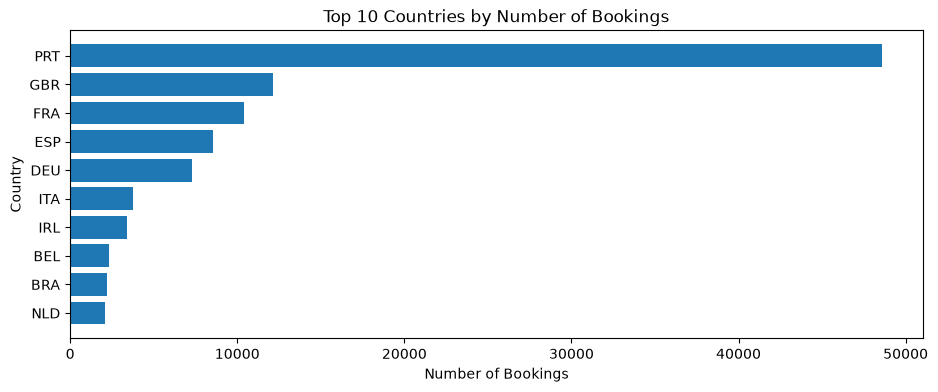

In [47]:
fig, ax = plt.subplots(figsize=(11, 4))

country_value_counts = (
    clean_df['country']
        .value_counts()
        .head(10)
)


ax.barh(country_value_counts.index, country_value_counts.values)

ax.invert_yaxis()

ax.set_title('Top 10 Countries by Number of Bookings')
ax.set_xlabel('Number of Bookings')
ax.set_ylabel('Country')

plt.show()